In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim


In [2]:
T = 5.0
N = 50
dt = T / (N - 1)
t = np.linspace(0, T, N)


In [3]:
def optimize_trajectory(q_start, q_end):
    def cost(x):
        q = x.reshape(2, N)
        dq = np.gradient(q, dt, axis=1)
        ddq = np.gradient(dq, dt, axis=1)
        return np.sum(ddq**2)

    def constraint(x):
        q = x.reshape(2, N)
        return [
            q[0,0] - q_start[0],
            q[1,0] - q_start[1],
            q[0,-1] - q_end[0],
            q[1,-1] - q_end[1],
        ]

    q_init = np.vstack([
        np.linspace(q_start[0], q_end[0], N),
        np.linspace(q_start[1], q_end[1], N)
    ])

    res = minimize(
        cost,
        q_init.flatten(),
        constraints={'type': 'eq', 'fun': constraint},
        method='SLSQP'
    )

    return res.x.reshape(2, N)


In [4]:
num_samples = 200

X = []
Y = []

for _ in range(num_samples):
    q_start = np.random.uniform(-1.0, 1.0, size=2)
    q_end = np.random.uniform(-1.0, 1.0, size=2)

    traj = optimize_trajectory(q_start, q_end)

    X.append(np.hstack([q_start, q_end]))
    Y.append(traj.flatten())


In [5]:
X = np.array(X)
Y = np.array(Y)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [6]:
Y_train_reshaped = Y_train.reshape(-1, 2, N)
Y_test_reshaped  = Y_test.reshape(-1, 2, N)

y_mean = Y_train_reshaped.mean(axis=(0, 2))      # shape: (2,)
y_std  = Y_train_reshaped.std(axis=(0, 2)) + 1e-6


In [7]:
Y_train_norm = (Y_train_reshaped - y_mean[:, None]) / y_std[:, None]
Y_test_norm  = (Y_test_reshaped  - y_mean[:, None]) / y_std[:, None]

Y_train_norm = Y_train_norm.reshape(Y_train.shape)
Y_test_norm  = Y_test_norm.reshape(Y_test.shape)


In [8]:
class TrajectoryNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 2*N)
        )

    def forward(self, x):
        return self.net(x)


In [9]:
model = TrajectoryNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [10]:
epochs = 300
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train_norm, dtype=torch.float32)


for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_train_t)
    loss = criterion(output, Y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")


Epoch 50, Loss: 0.009488
Epoch 100, Loss: 0.001554
Epoch 150, Loss: 0.000873
Epoch 200, Loss: 0.000581
Epoch 250, Loss: 0.000417
Epoch 300, Loss: 0.000315


In [11]:
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test_norm, dtype=torch.float32)


with torch.no_grad():
    Y_pred = model(X_test_t)

mse = mean_squared_error(
    Y_test_t.numpy(),
    Y_pred.numpy()
)

print("Test MSE:", mse)


Test MSE: 0.0008909512544050813


In [12]:
idx = 0
q_start = X_test[idx][:2]
q_end = X_test[idx][2:]

traj_opt = optimize_trajectory(q_start, q_end)
traj_nn = Y_pred[idx].numpy().reshape(2, N)

# denormalize
traj_nn = traj_nn * y_std[:, None] + y_mean[:, None]


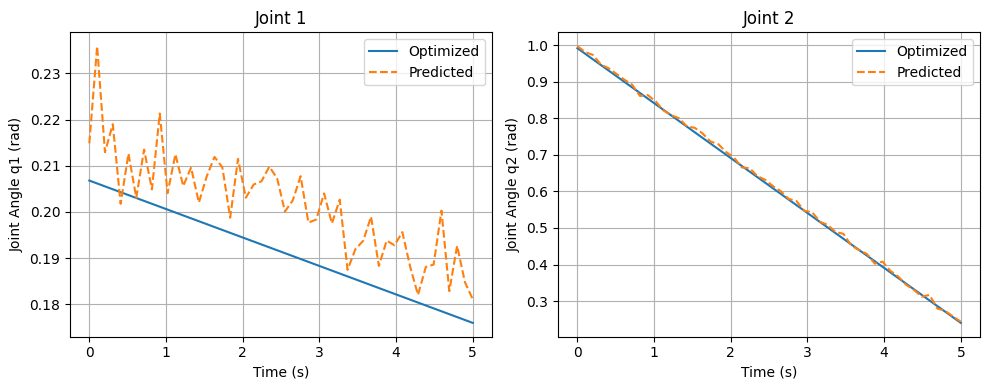

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, traj_opt[0], label="Optimized")
plt.plot(t, traj_nn[0], '--', label="Predicted")
plt.xlabel("Time (s)")
plt.ylabel("Joint Angle q1 (rad)")
plt.title("Joint 1")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t, traj_opt[1], label="Optimized")
plt.plot(t, traj_nn[1], '--', label="Predicted")
plt.xlabel("Time (s)")
plt.ylabel("Joint Angle q2 (rad)")
plt.title("Joint 2")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Optimizing trajectory...
Optimization successful! Final cost: 3.568556

Quartic trajectory cost: 4.965282
Optimized trajectory cost: 3.568556
Cost reduction: 28.13%


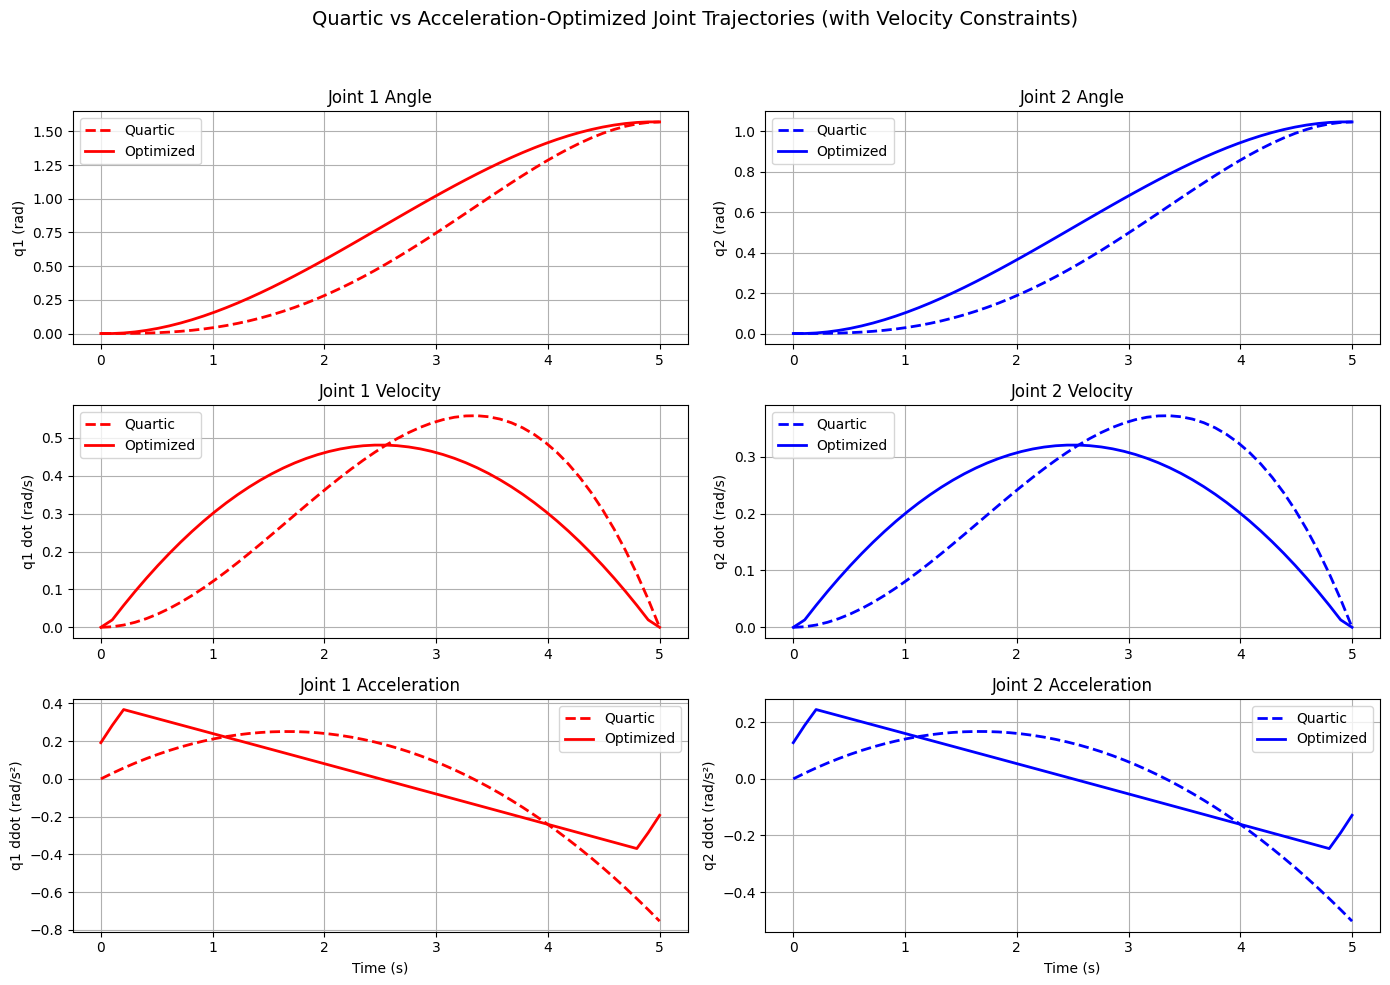

In [14]:
# ---------------- Parameters ----------------
T = 5.0
N = 50
dt = T / (N - 1)
t = np.linspace(0, T, N)

# Start and end joint angles
q1_start, q1_end = 0.0, np.pi / 2
q2_start, q2_end = 0.0, np.pi / 3


# ---------------- Quartic Trajectory ----------------
def quartic_trajectory(q_start, q_end):
    a0 = q_start
    a1 = 0
    a2 = 0

    A = np.array([
        [T ** 3, T ** 4],
        [3 * T ** 2, 4 * T ** 3]
    ])
    b = np.array([
        q_end - q_start,
        0
    ])

    a3, a4 = np.linalg.solve(A, b)

    q = a0 + a1 * t + a2 * t ** 2 + a3 * t ** 3 + a4 * t ** 4
    q_dot = a1 + 2 * a2 * t + 3 * a3 * t ** 2 + 4 * a4 * t ** 3
    q_ddot = 2 * a2 + 6 * a3 * t + 12 * a4 * t ** 2

    return q, q_dot, q_ddot


# Quartic baseline
q1_q, q1_dot, q1_ddot = quartic_trajectory(q1_start, q1_end)
q2_q, q2_dot, q2_ddot = quartic_trajectory(q2_start, q2_end)


# ---------------- Acceleration Cost Optimization ----------------
def acceleration_cost(x):
    q1 = x[:N]
    q2 = x[N:]

    cost = 0.0
    for k in range(1, N - 1):
        q1_dd = (q1[k + 1] - 2 * q1[k] + q1[k - 1]) / dt ** 2
        q2_dd = (q2[k + 1] - 2 * q2[k] + q2[k - 1]) / dt ** 2
        cost += q1_dd ** 2 + q2_dd ** 2
    return cost


# Initial guess
x0 = np.hstack([q1_q, q2_q])

# FIXED: Added velocity constraints at start and end points
constraints = [
    # Position constraints
    {'type': 'eq', 'fun': lambda x: x[0] - q1_start},
    {'type': 'eq', 'fun': lambda x: x[N - 1] - q1_end},
    {'type': 'eq', 'fun': lambda x: x[N] - q2_start},
    {'type': 'eq', 'fun': lambda x: x[2 * N - 1] - q2_end},

    # Velocity constraints (zero at start and end)
    {'type': 'eq', 'fun': lambda x: (x[1] - x[0]) / dt},  # q1_dot at start = 0
    {'type': 'eq', 'fun': lambda x: (x[N - 1] - x[N - 2]) / dt},  # q1_dot at end = 0
    {'type': 'eq', 'fun': lambda x: (x[N + 1] - x[N]) / dt},  # q2_dot at start = 0
    {'type': 'eq', 'fun': lambda x: (x[2 * N - 1] - x[2 * N - 2]) / dt}  # q2_dot at end = 0
]

print("Optimizing trajectory...")
result = minimize(acceleration_cost, x0, method='SLSQP', constraints=constraints,
                  options={'maxiter': 1000, 'ftol': 1e-9})

if result.success:
    print(f"Optimization successful! Final cost: {result.fun:.6f}")
else:
    print(f"Optimization warning: {result.message}")

q1_opt = result.x[:N]
q2_opt = result.x[N:]


# ---------------- Velocities and Accelerations ----------------
def velocity(q):
    return np.gradient(q, dt)


def acceleration(q):
    return np.gradient(np.gradient(q, dt), dt)


q1_dot_opt = velocity(q1_opt)
q2_dot_opt = velocity(q2_opt)

q1_ddot_opt = acceleration(q1_opt)
q2_ddot_opt = acceleration(q2_opt)

# Calculate and print costs
quartic_cost = acceleration_cost(np.hstack([q1_q, q2_q]))
optimized_cost = acceleration_cost(result.x)
print(f"\nQuartic trajectory cost: {quartic_cost:.6f}")
print(f"Optimized trajectory cost: {optimized_cost:.6f}")
print(f"Cost reduction: {((quartic_cost - optimized_cost) / quartic_cost * 100):.2f}%")

# ---------------- Combined Plot ----------------
plt.figure(figsize=(14, 10))

# Angles
plt.subplot(3, 2, 1)
plt.plot(t, q1_q, 'r--', label='Quartic', linewidth=2)
plt.plot(t, q1_opt, 'r', label='Optimized', linewidth=2)
plt.ylabel("q1 (rad)")
plt.title("Joint 1 Angle")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(t, q2_q, 'b--', label='Quartic', linewidth=2)
plt.plot(t, q2_opt, 'b', label='Optimized', linewidth=2)
plt.ylabel("q2 (rad)")
plt.title("Joint 2 Angle")
plt.legend()
plt.grid(True)

# Velocities
plt.subplot(3, 2, 3)
plt.plot(t, q1_dot, 'r--', label='Quartic', linewidth=2)
plt.plot(t, q1_dot_opt, 'r', label='Optimized', linewidth=2)
plt.ylabel("q1 dot (rad/s)")
plt.title("Joint 1 Velocity")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(t, q2_dot, 'b--', label='Quartic', linewidth=2)
plt.plot(t, q2_dot_opt, 'b', label='Optimized', linewidth=2)
plt.ylabel("q2 dot (rad/s)")
plt.title("Joint 2 Velocity")
plt.legend()
plt.grid(True)

# Accelerations
plt.subplot(3, 2, 5)
plt.plot(t, q1_ddot, 'r--', label='Quartic', linewidth=2)
plt.plot(t, q1_ddot_opt, 'r', label='Optimized', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("q1 ddot (rad/s²)")
plt.title("Joint 1 Acceleration")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(t, q2_ddot, 'b--', label='Quartic', linewidth=2)
plt.plot(t, q2_ddot_opt, 'b', label='Optimized', linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("q2 ddot (rad/s²)")
plt.title("Joint 2 Acceleration")
plt.legend()
plt.grid(True)

plt.suptitle("Quartic vs Acceleration-Optimized Joint Trajectories (with Velocity Constraints)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [15]:
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_traj(q1s, q2s, q1e, q2e):
    q_start = np.array([q1s, q2s])
    q_end   = np.array([q1e, q2e])

    # --- optimized trajectory ---
    traj_opt = optimize_trajectory(q_start, q_end)

    # --- predicted trajectory ---
    inp = torch.tensor([[q1s, q2s, q1e, q2e]], dtype=torch.float32)
    with torch.no_grad():
        traj_nn = model(inp).numpy().reshape(2, N)

    # --- plot ---
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.plot(t, traj_opt[0], label="Optimized")
    plt.plot(t, traj_nn[0], '--', label="Predicted")
    plt.xlabel("Time (s)")
    plt.ylabel("Joint Angle q1 (rad)")
    plt.title("Joint 1")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(t, traj_opt[1], label="Optimized")
    plt.plot(t, traj_nn[1], '--', label="Predicted")
    plt.xlabel("Time (s)")
    plt.ylabel("Joint Angle q2 (rad)")
    plt.title("Joint 2")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [16]:
interact(
    show_traj,
    q1s=FloatSlider(-1.5, step=0.1),
    q2s=FloatSlider(-1.5, step=0.1),
    q1e=FloatSlider(1.5, step=0.1),
    q2e=FloatSlider(1.5, step=0.1)
)


interactive(children=(FloatSlider(value=0.0, description='q1s'), FloatSlider(value=0.0, description='q2s'), Fl…

<function __main__.show_traj(q1s, q2s, q1e, q2e)>

In this assignment, optimized joint-space trajectories are created by performing optimization on joint accelerations. This optimized trajectory is then utilized to train the artificial neural network to predict the joint-space trajectory based on start and end joint angles. This trained model can determine the path much quickly than running the optimizer for each iteration. In Joint 2, the predicted path perfectly matches the optimized path. In Joint 1, the predictions were unsteady in the beginning since the movement of Joint 1 had limited variability. After applying output normalization, predictions for Joint 1 are greatly improved. This dashboard allows easy comparison of predictions and optimization plots for various inputs. Optimization predicts paths more accurately while learning-based predictions compute quickly and are apt for real-time systems.